# Week 6: Natural Language Processing — Sentiment Analysis

**Intern:** Fiza Zahid Ali  
**Discipline:** Bachelor of Science in Artificial Intelligence (BSAI)  
**Organization:** Zynxis  
**Internship:** AI / ML Internship  
**Week:** 6  

## Task

Build an NLP pipeline for sentiment analysis on student/intern feedback.

## 1. Project Objective

The objective of this task is to build a Natural Language Processing (NLP) pipeline that can analyze student/intern feedback and classify the sentiment of the feedback as positive or negative.

The NLP pipeline will include:

- Text cleaning
- Tokenization
- Stopword removal
- TF-IDF vectorization
- Machine Learning classification
- Sentiment prediction
- Sample input/output results

The goal is to demonstrate how NLP techniques can be used to transform unstructured text into useful information for an organization such as Zynxis.

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
data = {
    "feedback": [
        "The internship was an excellent learning experience",
        "I learned many useful machine learning skills",
        "The mentor was very supportive and helpful",
        "I enjoyed working on practical projects",
        "The training sessions were informative and useful",
        "I gained valuable experience during the internship",
        "The projects helped me improve my technical skills",
        "The internship provided a great learning environment",
        "The mentor explained concepts clearly",
        "I am very satisfied with this internship",

        "The internship was difficult and confusing",
        "I did not receive enough guidance",
        "The training sessions were not helpful",
        "I struggled to understand the project requirements",
        "The learning experience was disappointing",
        "There was not enough support from the mentor",
        "The tasks were unclear and difficult to complete",
        "I was unhappy with the overall experience",
        "The project instructions were confusing",
        "I did not enjoy the internship experience"
    ],

    "sentiment": [
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",

        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative"
    ]
}

df = pd.DataFrame(data)

df.head()

,feedback,sentiment
0,The internship was an excellent learning exper...,positive
1,I learned many useful machine learning skills,positive
2,The mentor was very supportive and helpful,positive
3,I enjoyed working on practical projects,positive
4,The training sessions were informative and useful,positive


In [6]:
#inspecting the dataset
print(df.shape)
df.isnull().sum()
df["sentiment"].value_counts()

(20, 2)


,count
sentiment,
positive,10
negative,10


## 2. Dataset Overview

A small labeled dataset of student/intern feedback was created for this demonstration.

Each feedback statement contains:

- `feedback` — the original text
- `sentiment` — the corresponding sentiment label

The dataset contains both positive and negative feedback examples, allowing a supervised NLP classification model to learn the relationship between text and sentiment.

In [7]:
stop_words = set(stopwords.words("english"))
def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return tokens

In [22]:
sample_text = df["feedback"][0]

print("Original text:")
print(sample_text)

print("\nTokens after preprocessing:")
print(preprocess_text(sample_text))

Original text:
The internship was an excellent learning experience

Tokens after preprocessing:
['internship', 'excellent', 'learning', 'experience']


## 6. Sample Input and Output

The trained NLP pipeline can process new student/intern feedback and predict its sentiment.

The complete process is:

**Input Text → Tokenization → Stopword Removal → TF-IDF Vectorization → Model Prediction**

In [9]:
df["tokens"] = df["feedback"].apply(preprocess_text)

df.head()

,feedback,sentiment,tokens
0,The internship was an excellent learning exper...,positive,"[internship, excellent, learning, experience]"
1,I learned many useful machine learning skills,positive,"[learned, many, useful, machine, learning, ski..."
2,The mentor was very supportive and helpful,positive,"[mentor, supportive, helpful]"
3,I enjoyed working on practical projects,positive,"[enjoyed, working, practical, projects]"
4,The training sessions were informative and useful,positive,"[training, sessions, informative, useful]"


In [10]:
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

df[["feedback", "clean_text", "sentiment"]].head()

,feedback,clean_text,sentiment
0,The internship was an excellent learning exper...,internship excellent learning experience,positive
1,I learned many useful machine learning skills,learned many useful machine learning skills,positive
2,The mentor was very supportive and helpful,mentor supportive helpful,positive
3,I enjoyed working on practical projects,enjoyed working practical projects,positive
4,The training sessions were informative and useful,training sessions informative useful,positive


## 3. Text Preprocessing

The text preprocessing pipeline performs the following operations:

1. Converts text to lowercase.
2. Removes punctuation and non-alphabetic characters.
3. Tokenizes the text into individual words.
4. Removes common English stopwords such as "the", "was", "and", and "is".
5. Combines the remaining tokens into cleaned text.

This preprocessing reduces unnecessary information and prepares the text for numerical vectorization.

In [12]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_text"])
X.shape
print(vectorizer.get_feature_names_out())

['clearly' 'complete' 'concepts' 'confusing' 'difficult' 'disappointing'
 'enjoy' 'enjoyed' 'enough' 'environment' 'excellent' 'experience'
 'explained' 'gained' 'great' 'guidance' 'helped' 'helpful' 'improve'
 'informative' 'instructions' 'internship' 'learned' 'learning' 'machine'
 'many' 'mentor' 'overall' 'practical' 'project' 'projects' 'provided'
 'receive' 'requirements' 'satisfied' 'sessions' 'skills' 'struggled'
 'support' 'supportive' 'tasks' 'technical' 'training' 'unclear'
 'understand' 'unhappy' 'useful' 'valuable' 'working']


In [13]:
y = df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
model = LogisticRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.75


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.67      1.00      0.80         2
    positive       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2 0]
 [1 1]]


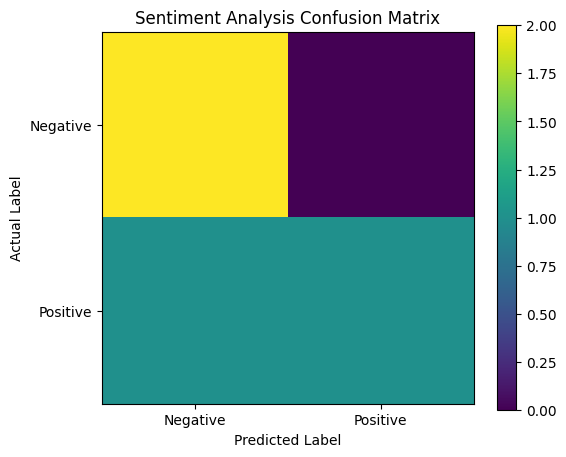

In [18]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Sentiment Analysis Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

plt.colorbar()

plt.show()

In [24]:
sample_feedback = input("Enter student/intern feedback: ")

# Preprocess text
cleaned_tokens = preprocess_text(sample_feedback)
cleaned_text = " ".join(cleaned_tokens)

# Convert text to TF-IDF
sample_vector = vectorizer.transform([cleaned_text])

# Predict sentiment
prediction = model.predict(sample_vector)[0]

print("\n" + "="*50)
print("NLP SENTIMENT ANALYSIS RESULT")
print("="*50)

print("\nOriginal Feedback:")
print(sample_feedback)

print("\nTokens After Preprocessing:")
print(cleaned_tokens)

print("\nCleaned Text:")
print(cleaned_text)

print("\nPredicted Sentiment:")
print(prediction.upper())

print("="*50)

Enter student/intern feedback: The internship was confusing and I did not receive enough support.

NLP SENTIMENT ANALYSIS RESULT

Original Feedback:
The internship was confusing and I did not receive enough support.

Tokens After Preprocessing:
['internship', 'confusing', 'receive', 'enough', 'support']

Cleaned Text:
internship confusing receive enough support

Predicted Sentiment:
NEGATIVE


## 4. Approach Explanation

The NLP pipeline begins by cleaning the feedback text and converting it into individual tokens. Common English stopwords are removed to reduce unnecessary words.

The cleaned text is then converted into numerical features using TF-IDF vectorization. TF-IDF allows the Machine Learning model to represent the importance of words within the feedback dataset.

A Logistic Regression classifier is trained using the TF-IDF features. The model learns patterns associated with positive and negative feedback and uses these patterns to classify new feedback.

The final pipeline can accept new student or intern feedback and return a predicted sentiment.

Because the demonstration dataset is small and manually created, the model's performance should not be interpreted as a production-level result. A real Zynxis implementation would require a much larger dataset containing authentic and appropriately labeled feedback.

 Limitations

This project uses a small demonstration dataset containing manually created feedback examples. Therefore, the model's performance cannot be considered representative of a production-level sentiment analysis system.

A real-world Zynxis system would require a larger dataset containing diverse and authentic student or intern feedback. The dataset would also need carefully verified sentiment labels.

Spelling errors, sarcasm, mixed sentiments, and context can also make sentiment classification challenging. More advanced NLP approaches, including transformer-based models, could be explored in future improvements.

## 5. Conclusion

In Week 6, a Natural Language Processing pipeline was developed to classify student/intern feedback as positive or negative.

The pipeline included text cleaning, tokenization, stopword removal, TF-IDF vectorization, supervised Machine Learning, and sentiment prediction.

The project demonstrated how unstructured textual feedback can be converted into numerical features and analyzed using Machine Learning.

This type of NLP system could potentially help Zynxis analyze large volumes of intern or student feedback and identify general sentiment trends automatically.